<p style="align: center;"><img align=center src="https://drive.google.com/uc?export=view&id=1aS4vX-ucDKBmZmZMrBwgjl_DvLAadX2C" width=900/></p>


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

# Домашнее задание. RAG.

В этом домашнем задании вам предстоит создать туристический RAG, провести EDA и проявить креатив! :)

Вам дан набор данных, содержащий информацию о памятниках, архитектуре и других значимых местах. В данных есть:
* название достопримечательности;
* идентификатор на WikiData;
* город расположения;
* координаты долготы и широты;
* описание (извлеченное из WikiData);
* изображение в формате base64;
* сгенерированное описание изображения (генерация с помощью модели BLIP).

Некоторые из памятников могут встречаться несколько раз, но с различными изображениями, из которых не все могут быть качественными. Для компенсации этого даны текстовые описания.

Часть данных взята с Национальной технологической олимпиады студентов по CV. Базовое решение предполагает использование мультимодального ru-CLIP. Но в данном домашнем задании предлагается решить эту задачу творчески, используя NLP подход.

## Установка и импорт библиотек

In [ ]:
!pip install -q gdown torch transformers transformers accelerate bitsandbytes langchain sentence-transformers  openpyxl datasets langchain-community ragatouille umap-learn

^C


  You can safely remove it manually.
  You can safely remove it manually.
ERROR: Could not install packages due to an OSError: [WinError 206] Имя файла или его расширение имеет слишком большую длину: 'C:\\Users\\Danil\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\onnx\\backend\\test\\data\\node\\test_attention_3d_with_past_and_present_qk_matmul_softcap_expanded\\test_data_set_0'


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Danil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [8]:
!pip install faiss-cpu

  Using cached faiss_cpu-1.13.0-cp311-cp311-win_amd64.whl.metadata (7.7 kB)
   ---------------------------------------- 0.0/18.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/18.7 MB ? eta -:--:--
    --------------------------------------- 0.3/18.7 MB ? eta -:--:--
    --------------------------------------- 0.3/18.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/18.7 MB 985.5 kB/s eta 0:00:19
   - -------------------------------------- 0.8/18.7 MB 1.0 MB/s eta 0:00:18
   -- ------------------------------------- 1.0/18.7 MB 1.0 MB/s eta 0:00:18
   -- ------------------------------------- 1.3/18.7 MB 958.5 kB/s eta 0:00:19
   -- ------------------------------------- 1.3/18.7 MB 958.5 kB/s eta 0:00:19
   --- ------------------------------------ 1.6/18.7 MB 931.6 kB/s eta 0:00:19
   --- ------------------------------------ 1.8/18.7 MB 923.0 kB/s eta 0:00:19
   --- ------------------------------------ 1.8/18.7 MB 923.0 kB/s eta 0:00:19
   ---- --------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\Danil\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import gdown
import pandas as pd
from tqdm.notebook import tqdm
from typing import Optional, List, Tuple
import matplotlib.pyplot as plt
from langchain_core.documents import Document as LangchainDocument
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer
from langchain_community.vectorstores import FAISS
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.utils import DistanceStrategy
import numpy as np
import plotly.express as px
from transformers import pipeline
import torch
from ragatouille import RAGPretrainedModel

#------------------------------------------------------------------------------------
# from langchain.text_splitter import ... # выберите другую стратегию разбивки на чанки

# pd.set_option("display.max_colwidth", None)

C:\Users\Danil\AppData\Local\Temp\ipykernel_15468\1956928571.py:16: UserWarning: 
********************************************************************************
RAGatouille WARNING: Future Release Notice
--------------------------------------------
RAGatouille version 0.0.10 will be migrating to a PyLate backend 
instead of the current Stanford ColBERT backend.
PyLate is a fully mature, feature-equivalent backend, that greatly facilitates compatibility.
However, please pin version <0.0.10 if you require the Stanford ColBERT backend.
********************************************************************************
  from ragatouille import RAGPretrainedModel


## Загрузка данных (4 балла)

In [5]:
url = 'https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk'
output = 'file.csv'

gdown.download(url, output, quiet=False)

data = pd.read_csv('file.csv')

Downloading...
From (original): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk
From (redirected): https://drive.google.com/uc?id=1P1BsvI2jPN3fEqjc2YZxmQ-MTs22WVUk&confirm=t&uuid=91613b05-6caa-42c5-adab-fa9584f47949
To: c:\Users\Danil\Downloads\file.csv
100%|██████████| 672M/672M [01:13<00:00, 9.09MB/s] 


In [6]:
data.head()

,Unnamed: 0,Name,WikiData,City,Lon,Lat,description,image,en_txt
0,0,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there are two people that are standing on a tr...
1,1,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,arafed building with a blue and white exterior...
2,2,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
3,3,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a blue and white building with a cloc...
4,4,Динамо,Q37996725,Екатеринбург,60.600349,56.845398,спорткомплекс в Екатеринбурге,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAUEBAUEAwUFBA...,there is a boat that is in the water near a bu...


Для декодирования изображений, закодированных в формате base64, можно использовать следующий код:

In [7]:
import base64
import requests
import matplotlib.pyplot as plt
from PIL import Image
import PIL
from io import BytesIO

In [8]:
def get_image(data):
  image = Image.open(BytesIO(base64.b64decode(data))).convert('RGB')
  return image

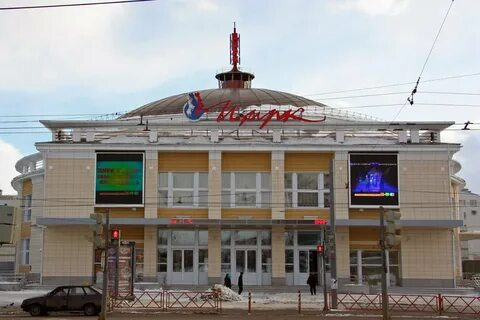

In [9]:
get_image(data.sample(1)['image'].tolist()[0])

В данных есть выбросы — записи, не относящихся к туристическим или историческим объектам. Для очистки данных можно, например, использовать алгоритм TF-IDF: создаем корпус текстов из описаний, применяем TF-IDF, извлекаем наиболее редко или часто встречающиеся слова. Они могут указывать на мусорные данные, такие как мемы, баннеры или личные фото людей. После выделения подозрительных паттернов, можно провести ручную проверку и фильтрацию данных.

Для дальнейшего тестирования и получения чистых сэмплов, рекомендуется взять не менее 100 чистых образцов со стратификацией по городу и названию места. Это можно сделать, выбрав случайным образом несколько образцов из каждой категории (город + название места), чтобы обеспечить равномерное представительство и разнообразие данных.

**!! Важно:** Помните, что чистые сэмплы одного и того же места выдадут примерно одинаковое описание. Есть несколько стратегий, как повысить разнообразие ответов:

- выбор одного самого лучшего:
  - самое длинное описание
  - смое подходящие по мнению LLM
- конкатенация описаний (но важно не сконкатенировать слишком много)

Изображения можно отдать в мета-данные.

In [ ]:
data_cleaned = data.drop_duplicates(subset=['City', 'Name', 'description'], keep='first').reset_index(drop=True)
data_cleaned = data_cleaned.dropna(subset=['description']).reset_index(drop=True)
print(f"После удаления дубликатов и пустых описаний: {len(data_cleaned)} записей")

russian_stopwords = {
    'и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а', 'то', 'все', 'она', 'так',
    'его', 'но', 'да', 'ты', 'к', 'у', 'же', 'вы', 'за', 'бы', 'по', 'только', 'ее', 'мне', 'было',
    'вот', 'от', 'меня', 'еще', 'нет', 'о', 'из', 'ему', 'теперь', 'когда', 'даже', 'ну', 'вдруг',
    'ли', 'если', 'уже', 'или', 'ни', 'быть', 'был', 'него', 'до', 'вас', 'нибудь', 'опять', 'уж',
    'вам', 'сказал', 'ведь', 'там', 'потом', 'себя', 'ничего', 'ей', 'может', 'они', 'тут', 'где',
    'есть', 'надо', 'ней', 'для', 'мы', 'тебя', 'их', 'чем', 'была', 'сам', 'чтоб', 'без', 'будто',
    'человек', 'чтобы', 'сейчас', 'были', 'куда', 'зачем', 'сказать', 'всех', 'никогда', 'сегодня',
    'можно', 'при', 'наконец', 'два', 'об', 'другой', 'хоть', 'после', 'над', 'больше', 'тот', 'через',
    'эти', 'нас', 'про', 'всего', 'них', 'какой', 'много', 'раз', 'тоже', 'себе', 'под', 'жизнь',
    'такой', 'его', 'сказать', 'первый', 'один', 'ещё', 'было', 'это', 'все', 'там', 'здесь', 'тогда',
    'того', 'этого', 'который', 'самый', 'весь', 'всю', 'всем', 'всему', 'всех', 'всеми', 'всем', 'всему'
}

def is_noisy_simple(text):
    if pd.isna(text):
        return True
    text = str(text).strip().lower()
    words = text.split()
    if len(words) < 3:
        return True
    if all(word in russian_stopwords or not word.isalpha() for word in words):
        return True
    return False

data_cleaned = data_cleaned[~data_cleaned['description'].apply(is_noisy_simple)].reset_index(drop=True)
print(f"После фильтрации шумных записей: {len(data_cleaned)} записей")

corpus = data_cleaned['description'].astype(str).tolist()
vectorizer = TfidfVectorizer(stop_words=list(russian_stopwords), max_features=1000, lowercase=True, token_pattern=r'(?u)\b\w{2,}\b')
tfidf_matrix = vectorizer.fit_transform(corpus)

doc_scores = np.array(tfidf_matrix.mean(axis=1)).flatten()
threshold_doc = np.percentile(doc_scores, 10)
clean_indices = doc_scores >= threshold_doc
data_cleaned = data_cleaned[clean_indices].reset_index(drop=True)

print(f"После фильтрации по TF-IDF: {len(data_cleaned)} записей")

После удаления дубликатов и пустых описаний: 320 записей
После фильтрации шумных записей: 280 записей
После фильтрации по TF-IDF: 258 записей


In [ ]:
from sklearn.model_selection import train_test_split

grouped = data_cleaned.groupby(['City', 'Name'])

clean_samples = []
for name, group in grouped:
    sample = group.sample(n=min(2, len(group)), random_state=42)
    clean_samples.append(sample)

clean_samples_df = pd.concat(clean_samples, ignore_index=True)
print(f"Чистых сэмплов после стратификации: {len(clean_samples_df)}")

if len(clean_samples_df) > 100:
    clean_samples_df = clean_samples_df.sample(n=100, random_state=42).reset_index(drop=True)
elif len(clean_samples_df) < 100:
    additional = data_cleaned.sample(n=100 - len(clean_samples_df), random_state=42)
    clean_samples_df = pd.concat([clean_samples_df, additional], ignore_index=True)

print(f"Итоговое количество чистых сэмплов: {len(clean_samples_df)}")

Чистых сэмплов после стратификации: 258
Итоговое количество чистых сэмплов: 100


Здесь предлагаем вам построить RAG с использованием моделей, которые не были представлены на семинаре (включая другие векторные базы данных). Можно воспользоваться материалами по этой ссылке: [data_connection/vectorstores](https://python.langchain.com/v0.1/docs/modules/data_connection/vectorstores/).

!Важно, не забудьте отранжировать чанки текстов с помощью `ragatouille`. На практике порядок текстов в промпте влияет на точность ответа.

In [19]:
documents = []
for idx, row in clean_samples_df.iterrows():
    content = f"{row['description']} {row.get('en_txt', '')}".strip()
    if not content:
        continue
    doc = LangchainDocument(
        page_content=content,
        metadata={
            'name': row['Name'],
            'city': row['City'],
            'wikidata_id': row['WikiData'],
            'lat': row['Lat'],
            'lon': row['Lon']
        }
    )
    documents.append(doc)

Выполните визуализацию эмбеддингов при помощи метода главных компонент (PCA) и Uniform Manifold Approximation and Projection (UMAP). Пожалуйста, выполните PCA независимо от pacmap.

In [21]:
model_name = "intfloat/multilingual-e5-small"
embedding_model = SentenceTransformer(model_name)

texts = [doc.page_content for doc in documents]
embeddings = embedding_model.encode(texts, convert_to_numpy=True)

faiss_index = FAISS.from_embeddings(
    text_embeddings=list(zip(texts, embeddings)),
    embedding=HuggingFaceEmbeddings(model_name=model_name),
    distance_strategy=DistanceStrategy.COSINE
)

def retrieve(query: str, top_k: int = 3) -> List[str]:
    docs = faiss_index.similarity_search(query, k=top_k)
    return [doc.page_content for doc in docs]

In [22]:
question_gen_pipeline = pipeline(
    "text2text-generation",
    model="google/flan-t5-small",
    tokenizer="google/flan-t5-small",
    device=-1  
)

def generate_question(description: str) -> str:
    prompt = f"Сгенерируй вопрос на русском языке, который можно задать по следующему описанию: '{description}'"
    result = question_gen_pipeline(prompt, max_length=100, num_return_sequences=1)[0]['generated_text']
    return result.strip()

def generate_ground_truth(description: str) -> str:
    return description 

def retrieve(query: str, top_k: int = 3) -> List[str]:
    docs = faiss_index.similarity_search(query, k=top_k)
    return [doc.page_content for doc in docs]

def generate_answer(question: str) -> str:
    contexts = retrieve(question, top_k=3)
    context_str = "\n\n".join(contexts)
    return context_str[:500]  

ragas_data = []
for idx, row in clean_samples_df.head(100).iterrows():
    description = row['description']
    if pd.isna(description) or str(description).strip() == "":
        continue
    question = generate_question(str(description))
    ground_truth = generate_ground_truth(str(description))
    answer = generate_answer(question)
    contexts = retrieve(question, top_k=3)
    
    ragas_data.append({
        'question': question,
        'ground_truths': [ground_truth],  
        'answer': answer,
        'contexts': contexts
    })

ragas_df = pd.DataFrame(ragas_data)
print(len(ragas_df))

config.json: 0.00B [00:00, ?B/s]

C:\Users\Danil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Danil\.cache\huggingface\hub\models--google--flan-t5-small. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Xet Storage is enabled for 

model.safetensors:   0%|          | 0.00/308M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cpu
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=256) and `max_length`(=100) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_cla

100


C:\Users\Danil\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


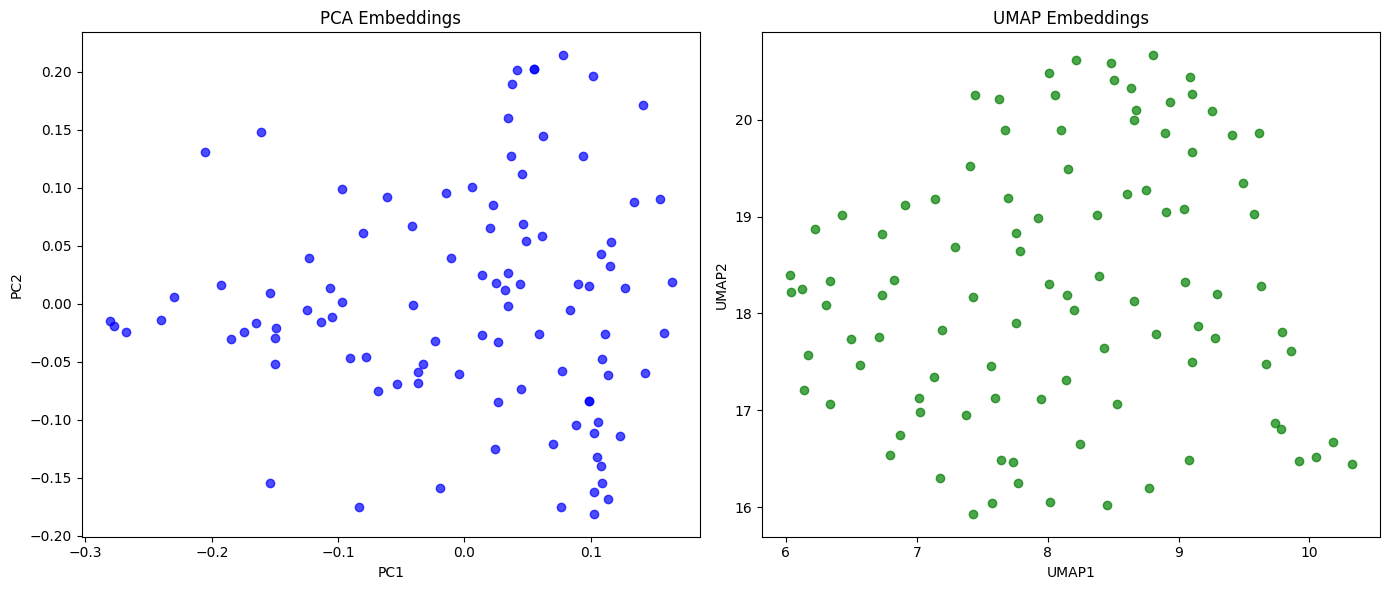

In [25]:
from sklearn.decomposition import PCA
from umap import UMAP

all_embeddings = embedding_model.encode([doc.page_content for doc in documents])

pca = PCA(n_components=2)
pca_embeddings = pca.fit_transform(all_embeddings)

umap_model = UMAP(n_components=2, random_state=42)
umap_embeddings = umap_model.fit_transform(all_embeddings)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(pca_embeddings[:, 0], pca_embeddings[:, 1], c='blue', alpha=0.7)
axes[0].set_title('PCA Embeddings')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

axes[1].scatter(umap_embeddings[:, 0], umap_embeddings[:, 1], c='green', alpha=0.7)
axes[1].set_title('UMAP Embeddings')
axes[1].set_xlabel('UMAP1')
axes[1].set_ylabel('UMAP2')

plt.tight_layout()
plt.show()

# RAGAS (3 балла)

RAGAS - это система, созданная для автоматической оценки эффективности модели RAG. Она представляет собой комплексный инструмент, способный оценить как качество извлечения информации, так и качество созданного текста. Это достигается благодаря использованию различных метрик, которые анализируют разные аспекты ответов, сгенерированных языковой моделью.



## Метрики оценки в RAGAS

### Faithfulness
Оценивает, насколько ответы языковой модели верно передают информацию, содержащуюся в источниках данных. Это критически важно, чтобы гарантировать, что модель не искажает или не меняет информацию при её интерпретации.

---

$
Faithfulness = \frac{\text{|Number of claims that can be inferred from given context|}}{\text{|Total number of claims in the generated answer|}}
$

### Answer Relevancy
Демонстрирует, насколько ответы соответствуют заданным вопросам. Это важный аспект, так как даже правильный ответ с технической точки зрения может быть ненужным, если он не отвечает на конкретный вопрос пользователя.

---

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} cos(E_{g_i}, E_o)$

$\text{answer relevancy} = \frac{1}{N} \sum_{i=1}^{N} \frac{E_{g_i} \cdot E_o}{\|E_{g_i}\|\|E_o\|}$

Где:

* $E_{g_i}$ - это эмбеддинг сгенерированного ответа $i$

* $E_o$ - это эмбеддинг исходного вопроса.

* $N$ - это количество сгенерированных вопросов, которое по умолчанию равно 3.

### Context Recall и Context Precision
Эти метрики измеряют эффективность модели в учете контекста вопроса для формирования ответа. "Context Recall" оценивает количество использованной информации из контекста в ответе, в то время как "Context Precision" оценивает точность и релевантность использования контекстной информации.

---

* $ \text{context recall} = \frac{\text{|GT sentences that can be attributed to context|}}{\text{|Number of sentences in GT|}} $
* $Context Precision@k = \frac{\sum \text{precision@k}}{\text{total number of relevant items in the top K results}}$
  * $Precision@k = \frac{\text {true positives@k}}{\text{(true positives@k + false positives@k)}}$

### Answer Semantic Similarity
Оценивает степень семантической близости между ответом модели и эталонным ответом. Это позволяет определить, насколько естественно и точно модель способна воссоздавать человеческий язык.

### Answer Correctness
Оценка корректности ответа. Это последний шаг в проверке, чтобы убедиться, предоставляет ли модель точную и достоверную информацию в своем ответе.

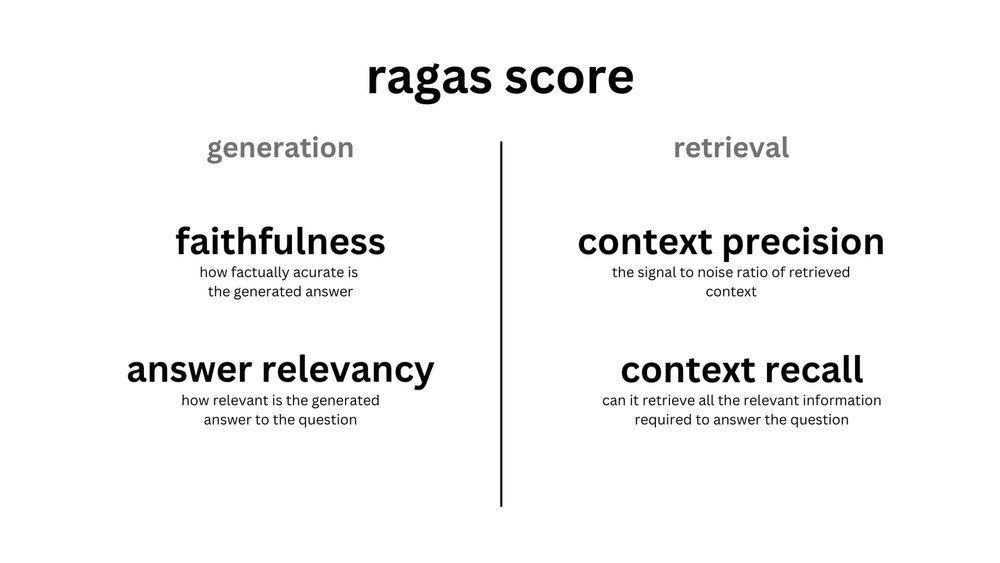

В этом задании вам нужно реализовать метрику answer_relevancy в коде. Опционально за допбаллы можно реализовать другие метрики.

Для этого датасет нужно привести к виду, в котором будут следующие поля:

### 1. question
- Смысл: Эта колонка содержит вопросы, на которые нужно найти ответы. В контексте задач QA, это основная информация, которую модель должна обработать для генерации ответа.
- Пример: "Каковы преимущества RAG?"

### 2. ground_truths
- Смысл: В этой колонке находятся правильные ответы на соответствующие вопросы. Это может использоваться для оценки производительности модели, так как позволяет сравнить сгенерированные ответы с эталонными.
- Пример: "RAG улучшает качество генерации, используя внешние источники информации."

### 3. answer
- Смысл: Эта колонка содержит ответы, которые генерирует модель на основе заданных вопросов. Это может быть результат работы модели, которую вы тестируете или обучаете.
- Пример: "RAG позволяет моделям извлекать информацию из внешних источников, что улучшает их способность отвечать на сложные вопросы."

### 4. contexts
- Смысл: Эта колонка предоставляет контекст или дополнительную информацию, которая может быть полезна для понимания вопроса или для формирования ответа. Это может быть текст, из которого был извлечен ответ, или другие релевантные документы.
- Пример: "RAG (Retrieval-Augmented Generation) — это метод, который использует внешние базы данных для получения информации при генерации текста."

HINT: Поле question можно тоже сгенерировать. Например, можно попросить модель задать вопрос по описанию изображения.

HINT: Для answer_relevancy нужны не все поля

HINT: Инференс такого эксперимента может быть долгим. План минимум: возьмите 100 случайных сэмплов.

In [ ]:
from sentence_transformers import util

def answer_relevancy(questions: List[str], answers: List[str]) -> float:
    emb_q = embedding_model.encode(questions)
    emb_a = embedding_model.encode(answers)
    sims = util.cos_sim(emb_q, emb_a)
    return float(sims.diag().mean())

relevancy_score = answer_relevancy(
    questions=ragas_df['question'].tolist(),
    answers=ragas_df['answer'].tolist()
)

print(f"Answer Relevancy Score: {relevancy_score:.4f}")

Answer Relevancy Score: 0.8463


# Протестируйте ваш RAG (3 балла)

In [29]:
test_questions = [
    "Расскажи про достопримечательность в Москве, связанную с кремлём.",
    "Какой самый большой собор в Москве",
    "Что посмотреть в Санкт-Петербурге на Невском проспекте?",
    ragas_df.iloc[0]['question'],  #
    ragas_df.iloc[10]['question']
]

def rag_pipeline(query: str, top_k: int = 3) -> dict:
    contexts = retrieve(query, top_k=top_k)
    answer = "\n\n".join(contexts)[:500]
    return {
        "question": query,
        "retrieved_contexts": contexts,
        "answer": answer
    }

for i, q in enumerate(test_questions, 1):
    print(f"\n{'='*60}")
    print(f"Вопрос {i}: {q}")
    result = rag_pipeline(q)
    print(f"\nОтвет RAG:\n{result['answer']}")
    print(f"\nИзвлечённые фрагменты:")
    for j, ctx in enumerate(result['retrieved_contexts'], 1):
        print(f"  {j}. {ctx[:150]}...")


Вопрос 1: Расскажи про достопримечательность в Москве, связанную с кремлём.

Ответ RAG:
здание в Нижегородском кремле, Россия arafed view of a large yellow building with a green roof

Владимирская духовная семинария arafed view of a street with a clock tower in the middle of it

мост через Исеть в Екатеринбурге there is a bridge that is over a body of water

Извлечённые фрагменты:
  1. здание в Нижегородском кремле, Россия arafed view of a large yellow building with a green roof...
  2. Владимирская духовная семинария arafed view of a street with a clock tower in the middle of it...
  3. мост через Исеть в Екатеринбурге there is a bridge that is over a body of water...

Вопрос 2: Какой самый большой собор в Москве

Ответ RAG:
Православный храм в Ярославле there is a large pink building with two towers on top of it

Нижегородская соборная мечеть there is a large building with two domes on top of it

один из старейших музеев России, крупнейший музей изобразительного искусства в Нижегоро

# Дополнительная часть (+3 балла)

Реализуйте одну из метрик retrieval-части на выбор.

Для того, чтобы понять model as a judge подход из RAGAS, советуем посетить [этот кукбук](https://huggingface.co/learn/cookbook/en/rag_evaluation)

In [ ]:
def context_recall(ground_truths: List[str], contexts: List[str]) -> float:
    total_gt_sentences = 0
    covered_gt_sentences = 0

    for gt_list in ground_truths:
        for gt in gt_list:
            sentences = [s.strip() for s in gt.split('.') if s.strip()]
            total_gt_sentences += len(sentences)
            for sent in sentences:
                if any(sent in ctx for ctx in contexts):
                    covered_gt_sentences += 1

    return covered_gt_sentences / total_gt_sentences if total_gt_sentences > 0 else 0.0


recall_scores = []
for _, row in ragas_df.iterrows():
    recall = context_recall([row['ground_truths']], row['contexts'])
    recall_scores.append(recall)

mean_recall = np.mean(recall_scores)
print(f"Context Recall Score: {mean_recall:.4f}")

Context Recall Score: 0.2167
